# Extract x1dbk1, x1dtrace, and x1dbk2 from test-data

This notebook builds on `inspiration/extraction_script.py` and focuses on the test data in `test-data/`. It will:

- create `x1d` files if they do not exist
- extract `x1dbk1`, `x1dtrace`, and `x1dbk2` using the same offsets/sizes logic

The trace selection is interactive using `%matplotlib widget` and `ipywidgets`, so the plot should appear inline.

Run the cells top to bottom.

In [1]:
%matplotlib widget

import os
import sys
sys.path.append("../")
from astropy.io import fits

import extraction_utils as extract_utils

# Optional: set CRDS paths if they are not already configured.
# Update CRDS_PATH to match your local cache location if needed.
CRDS_PATH = "/Users/parke/crds_cache"
if "CRDS_PATH" not in os.environ:
    os.environ["CRDS_PATH"] = CRDS_PATH
    os.environ.setdefault("CRDS_SERVER_URL", "https://hst-crds.stsci.edu")
    os.environ.setdefault("iref", f"{CRDS_PATH}/references/hst/iref/")
    os.environ.setdefault("jref", f"{CRDS_PATH}/references/hst/jref/")
    os.environ.setdefault("oref", f"{CRDS_PATH}/references/hst/oref/")
    os.environ.setdefault("lref", f"{CRDS_PATH}/references/hst/lref/")
    os.environ.setdefault("nref", f"{CRDS_PATH}/references/hst/nref/")
    os.environ.setdefault("uref", f"{CRDS_PATH}/references/hst/uref/")

/Users/parke/mamba/envs/stenv/lib/python3.13/site-packages/stsci/tools/nmpfit.py:8: UserWarning: NMPFIT is deprecated - stsci.tools v 3.5 is the last version to contain it.
  warnings.warn("NMPFIT is deprecated - stsci.tools v 3.5 is the last version to contain it.")
/Users/parke/mamba/envs/stenv/lib/python3.13/site-packages/stsci/tools/gfit.py:18: UserWarning: GFIT is deprecated - stsci.tools v 3.4.12 is the last version to contain it.Use astropy.modeling instead.
  warnings.warn("GFIT is deprecated - stsci.tools v 3.4.12 is the last version to contain it."


The following tasks in the stistools package can be run with TEAL:
   basic2d      calstis     ocrreject     wavecal        x1d          x2d


In [2]:
TEST_DATA_DIR = extract_utils.find_test_data_dir()
flt_files = sorted(TEST_DATA_DIR.glob("*_flt.fits"))

print(f"Test data dir: {TEST_DATA_DIR}")
print("FLT files:")
for f in flt_files:
    print(f"- {f.name}")

Test data dir: /Users/parke/Repos/airglow/test-data
FLT files:
- of9b05010_flt.fits
- of9b05020_flt.fits
- of9b05030_flt.fits


In [3]:
# Pick a single file at a time.
TARGET_FILE = TEST_DATA_DIR / "of9b05030_flt.fits"
print(f"Target: {TARGET_FILE.name}")

Target: of9b05030_flt.fits


Label(value='Click on the image to select the trace location.')

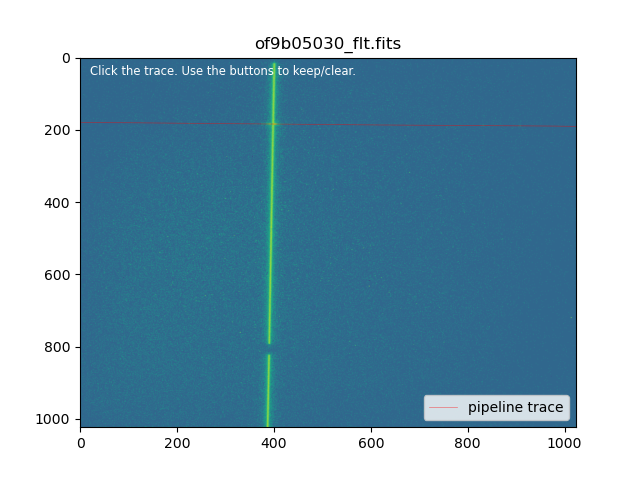

In [4]:
# Display the interactive plot and click to select the trace.
# Use the buttons below the plot to use the default or clear the selection.
fig, ax = extract_utils.setup_trace_selector(TARGET_FILE)

In [5]:
# Run the extractions using the selected trace location.
trace_y = (
    extract_utils.SELECTED_TRACE_Y
    if extract_utils.SELECTED_TRACE_Y is not None
    else extract_utils.DEFAULT_TRACE_Y
)
if trace_y is None:
    raise ValueError("No trace selected and no default trace available.")
else:
    print(f"Using trace y: {trace_y}")

extract_utils.extract_standard_x1d(
    TARGET_FILE,
    overwrite=True,
    manual_traceloc=trace_y,
)

print(f"Using trace y: {trace_y}")
extract_utils.extract_background_traces(
    TARGET_FILE,
    overwrite=True,
    manual_traceloc=trace_y,
)

Using trace y: 186.35364043875722

*** CALSTIS-6 -- Version 3.4.2 (19-Jan-2018) ***
Begin    06-Feb-2026 17:18:12 PST

INFO     'D1' has been appended to aperture
Warning  Grating-aperture throughput correction table (GACTAB) was not found,
         and no gac corrections will be applied
Input    /Users/parke/Repos/airglow/test-data/of9b05030_flt.fits
Output   /Users/parke/Repos/airglow/test-data/of9b05030_x1d.fits
Rootname of9b05030
OBSMODE  TIME-TAG
APERTURE 52X0.1D1
OPT_ELEM G140M
DETECTOR FUV-MAMA

XTRACTAB oref$n7p10323o_1dx.fits
XTRACTAB PEDIGREE=INFLIGHT 29/05/97
XTRACTAB DESCRIP =Analysis from prop. 7064 and ground data
XTRACTAB DESCRIP =Analysis from prop. 7064
SPTRCTAB oref$77o1827do_1dt.fits
SPTRCTAB PEDIGREE=INFLIGHT 27/02/1997 01/12/2009
SPTRCTAB DESCRIP =New traces for select echelle secondary modes

Imset 1  Begin 17:18:12 PST
         Input read into memory.
Order 1  Begin 17:18:13 PST
X1DCORR  PERFORM
BACKCORR PERFORM
******** Calling Slfit ***********BACKCORR COMPLETE

In [6]:
print("\nOutputs:")
for suffix in ("x1dbk1", "x1dtrace", "x1dbk2"):
    out = TARGET_FILE.with_name(TARGET_FILE.name.replace("_flt", f"_{suffix}"))
    print(f"- {out.name} ({'exists' if out.exists() else 'missing'})")
    if out.exists():
        a2center = fits.getdata(out, 1)["a2center"]
        print(f"  a2center: {a2center}")


Outputs:
- of9b05030_x1dbk1.fits (exists)
  a2center: [156.35364]
- of9b05030_x1dtrace.fits (exists)
  a2center: [186.35364]
- of9b05030_x1dbk2.fits (exists)
  a2center: [216.35364]


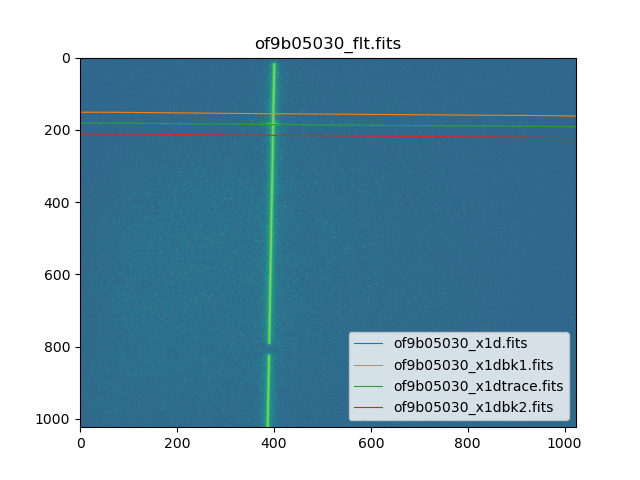

In [7]:
# Plot the extraction locations for the generated x1d files on the FLT image.
fig, ax = extract_utils.plot_extraction_locations(TARGET_FILE)

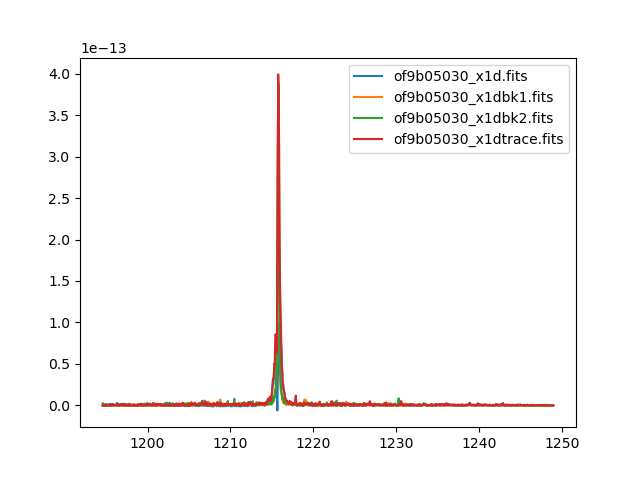

In [8]:
from matplotlib import pyplot as plt
from astropy.io import fits

root = TARGET_FILE.name.split("_")[0]
x1d_files = sorted(TEST_DATA_DIR.glob(f"{root}*x1d*.fits"))

plt.figure()
for file in x1d_files:
    h = fits.open(file)
    w, f = [h[1].data[k][0] for k in ("WAVELENGTH", "FLUX")]
    plt.plot(w, f, label=file.name)
plt.legend()